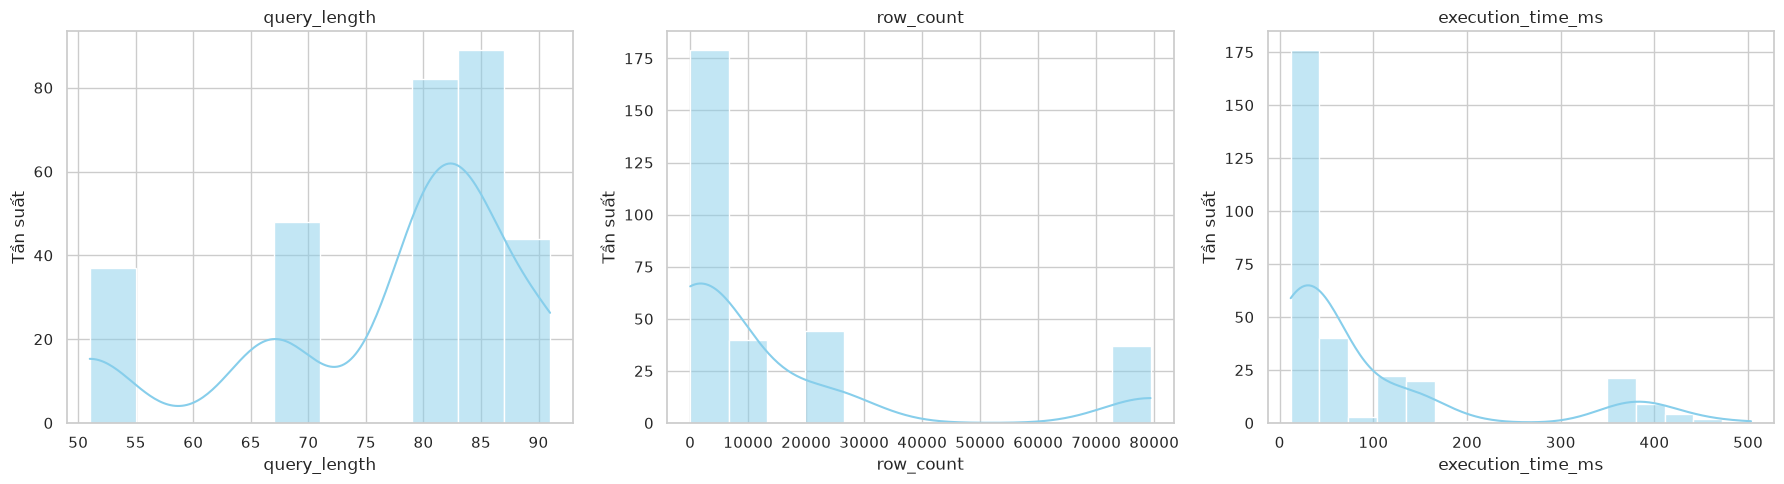

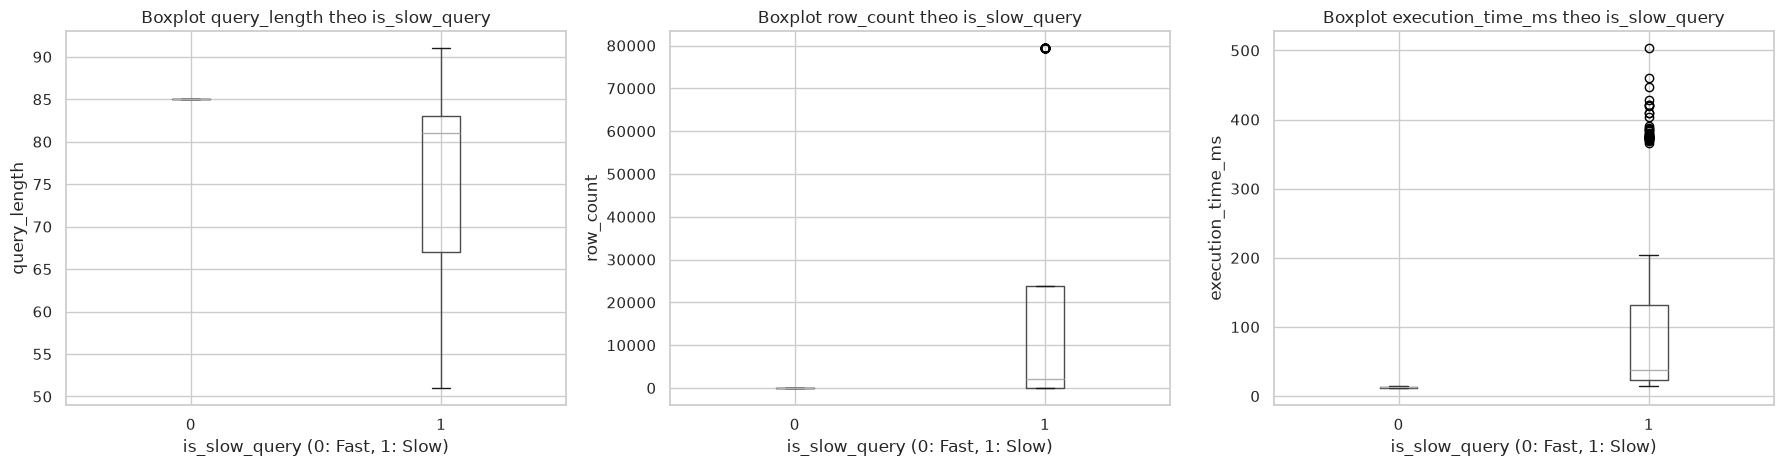

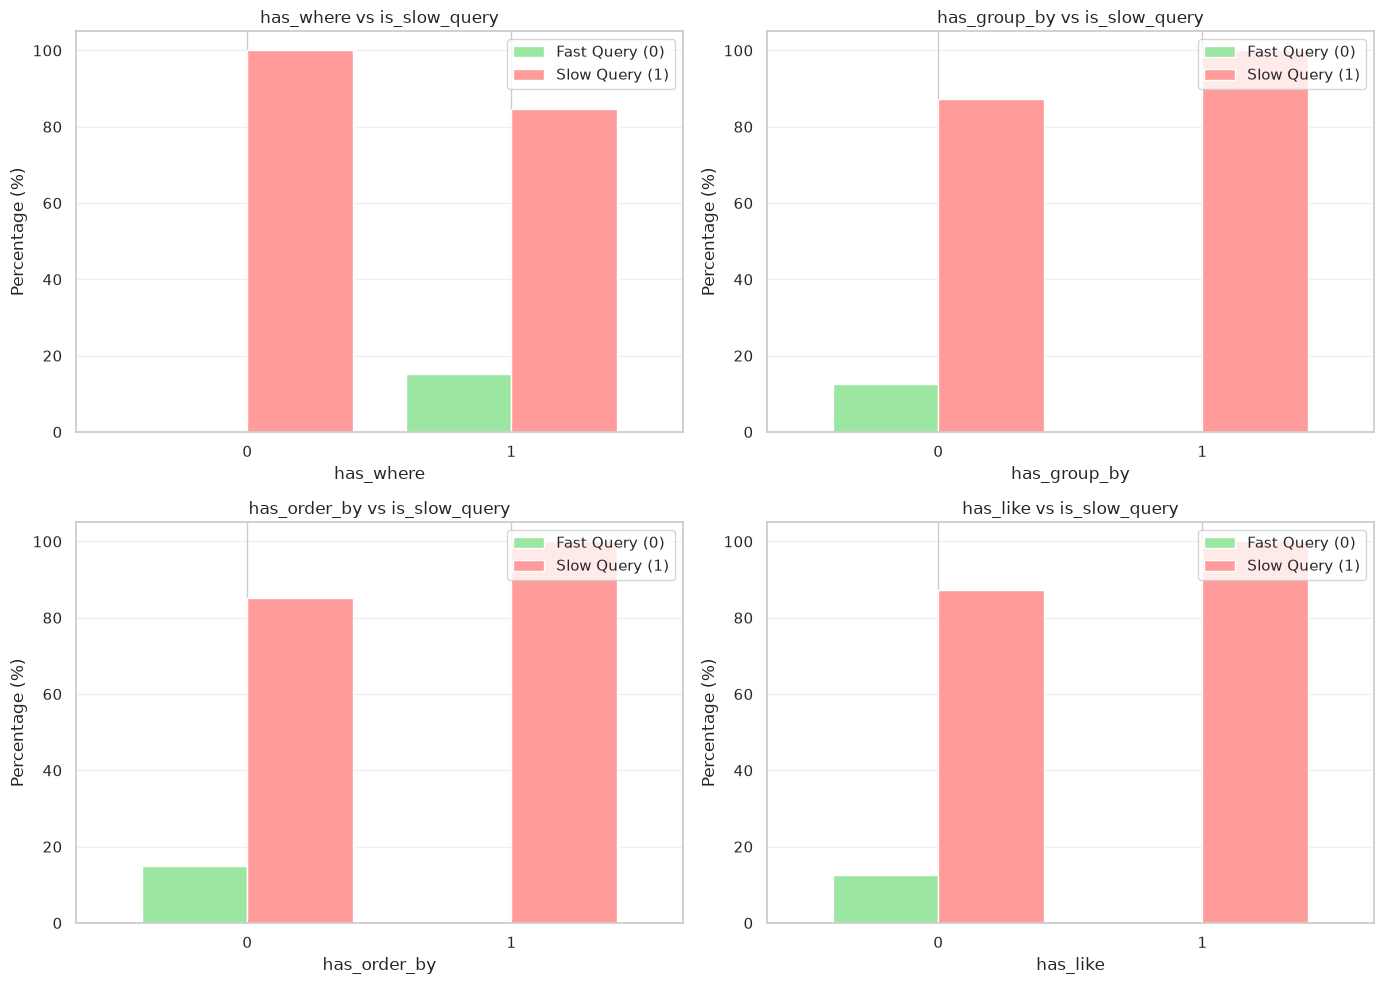

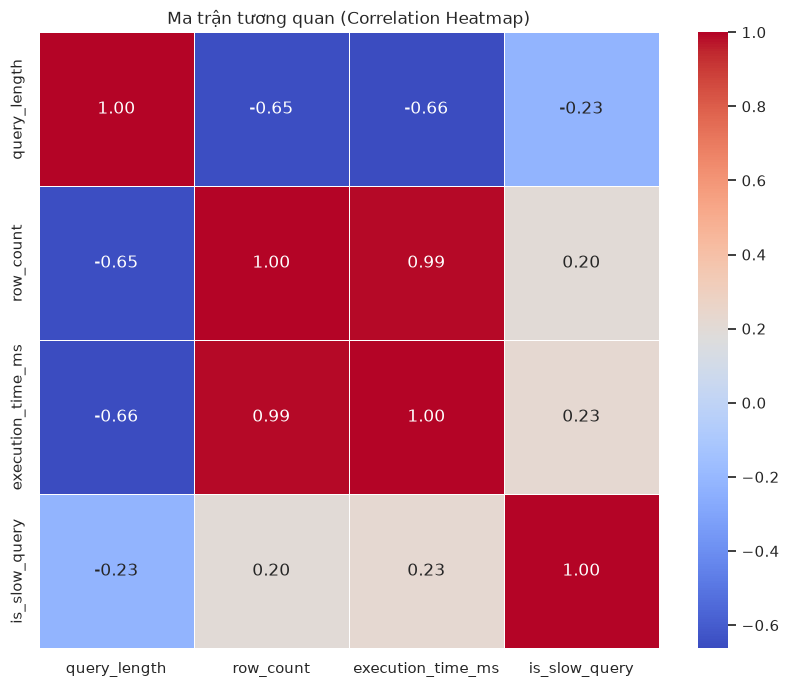

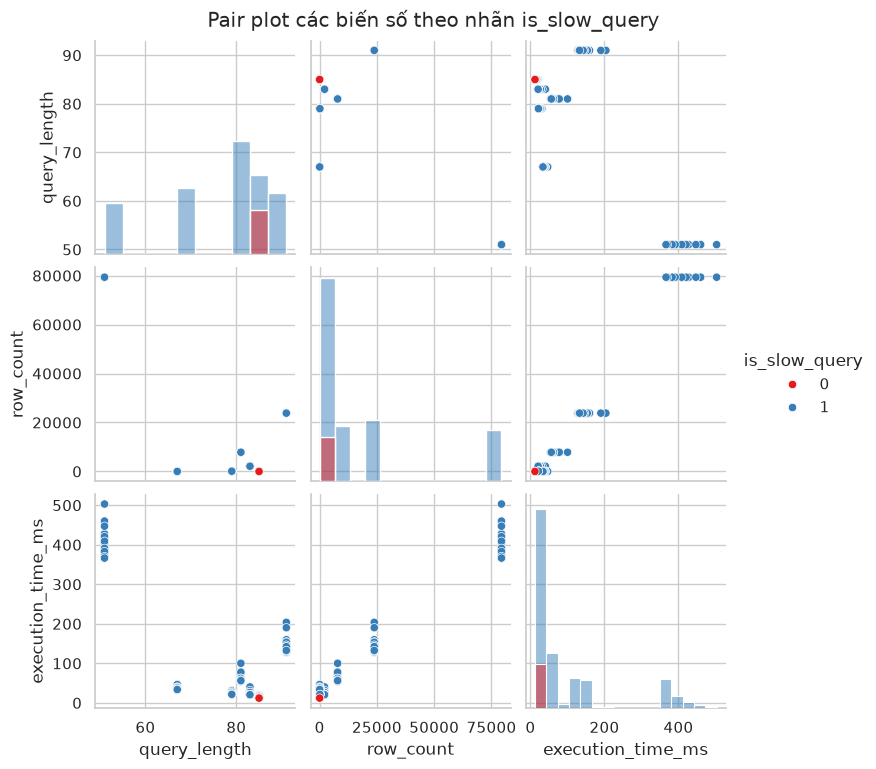

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách hiển thị chung cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df = pd.read_csv('dataset_raw.csv')

# ==========================================
# 1. 3 HISTOGRAM CHO CÁC BIẾN SỐ
# ==========================================
num_cols = ['query_length', 'row_count', 'execution_time_ms']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tần suất')
plt.tight_layout()
plt.show()

# ==========================================
# 2. 3 BOX PLOT THEO BIẾN MỤC TIÊU is_slow_query
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['query_length', 'row_count', 'execution_time_ms']

for i, col in enumerate(num_cols):

    df.boxplot(column=col, by='is_slow_query', ax=axes[i], grid=True)
    axes[i].set_title(f'Boxplot {col} theo is_slow_query')
    axes[i].set_xlabel('is_slow_query (0: Fast, 1: Slow)')
    axes[i].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

# ==========================================
# 3. 4 BAR PLOT CHO CÁC ĐẶC TRƯNG PHÂN LOẠI (Gộp vào 1 hình 2x2)
# ==========================================
cat_cols = ['has_where', 'has_group_by', 'has_order_by', 'has_like']
cat_cols = [c for c in cat_cols if c in df.columns]

if len(cat_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols[:4]):
        cross_tab = pd.crosstab(df[col], df['is_slow_query'], normalize='index') * 100

        cross_tab.plot(kind='bar', ax=axes[i], color=['#9be7a1', '#ff9b9b'], width=0.8)
        
        axes[i].set_title(f'{col} vs is_slow_query')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Percentage (%)')
        axes[i].legend(['Fast Query (0)', 'Slow Query (1)'], loc='upper right')
        axes[i].grid(True, axis='y', alpha=0.3)
        axes[i].tick_params(axis='x', rotation=0)
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 1 HEATMAP TƯƠNG QUAN
# ==========================================
plt.figure(figsize=(10, 8))
corr_cols = num_cols + ['is_slow_query']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

# ==========================================
# 5. 1 PAIR PLOT
# ==========================================
sns.pairplot(df[num_cols + ['is_slow_query']], hue='is_slow_query', palette='Set1', diag_kind='hist')
plt.suptitle('Pair plot các biến số theo nhãn is_slow_query', y=1.02)
plt.show()

## ==========================================
# Chương 14: Huấn luyện và Đánh giá mô hình XGBoost
## ==========================================

Mô hình được huấn luyện trên 5 đặc trưng cấu trúc (không dùng `row_count`/`execution_time_ms`
để tránh rò rỉ dữ liệu, vì `execution_time_ms` chính là biến gốc sinh ra nhãn `is_slow_query`).

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, auc,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')

df = pd.read_csv('dataset_raw.csv')
feature_cols = ['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']
X, y = df[feature_cols], df['is_slow_query']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    objective='binary:logistic', eval_metric='auc', max_depth=6, learning_rate=0.1,
    n_estimators=100, subsample=0.8, colsample_bytree=0.8, random_state=42, base_score=0.5,
    use_label_encoder=False,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('=== ĐÁNH GIÁ MODEL (Tập kiểm thử 60 mẫu) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
print()
print(classification_report(y_test, y_pred, digits=3))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\n=== 5-FOLD CROSS-VALIDATION ===')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print('AUC từng fold:', np.round(cv_auc, 4))
print(f'AUC trung bình: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

print('\n=== FEATURE IMPORTANCE (gốc XGBoost) ===')
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(feat_imp.round(4))

print('\n=== PERMUTATION IMPORTANCE ===')
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
print(perm_imp.round(4))

In [ ]:
# ==========================================
# Hình 7: Feature Importance + ROC + Confusion Matrix + Probability Distribution
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importance
sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=axes[0, 0], palette='viridis', orient='h')
axes[0, 0].set_title('Feature Importance (XGBoost)')
axes[0, 0].set_xlabel('Độ quan trọng')
axes[0, 0].set_ylabel('Đặc trưng')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Fast (0)', 'Slow (1)'], yticklabels=['Fast (0)', 'Slow (1)'])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Dự đoán')
axes[1, 0].set_ylabel('Thực tế')

# 4. Probability Distribution Plot
for cls, color in [(0, '#4C72B0'), (1, '#C44E52')]:
    proba_cls = y_pred_proba[y_test.values == cls]
    sns.histplot(proba_cls, bins=15, kde=True, color=color, ax=axes[1, 1], alpha=0.6,
                 label=f'True class {cls}')
axes[1, 1].set_title('Phân bố xác suất dự đoán theo nhãn thực')
axes[1, 1].set_xlabel('P(chậm)')
axes[1, 1].set_ylabel('Số lượng')
axes[1, 1].legend()

plt.suptitle('Hình 7: Kết quả đánh giá mô hình XGBoost', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Hình 8: Top Feature Importance (XGBoost + Permutation) + ROC + Confusion Matrix
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top Feature Importance (XGBoost)
sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=axes[0, 0], palette='viridis', orient='h')
axes[0, 0].set_title('Top Feature Importance (XGBoost)')
axes[0, 0].set_xlabel('Độ quan trọng')
axes[0, 0].set_ylabel('Đặc trưng')

# 2. Top Feature Importance (Permutation)
sns.barplot(x=perm_imp.values, y=perm_imp.index, ax=axes[0, 1], palette='magma', orient='h')
axes[0, 1].set_title('Top Feature Importance (Permutation)')
axes[0, 1].set_xlabel('Độ quan trọng')
axes[0, 1].set_ylabel('Đặc trưng')

# 3. ROC Curve
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend(loc='lower right')

# 4. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Fast (0)', 'Slow (1)'], yticklabels=['Fast (0)', 'Slow (1)'])
axes[1, 1].set_title('Confusion Matrix')
axes[1, 1].set_xlabel('Dự đoán')
axes[1, 1].set_ylabel('Thực tế')

plt.suptitle('Hình 8: Đánh giá hiệu suất mô hình XGBoost', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()